In [1]:

# Install/upgrade the libraries this notebook needs.
# On Kaggle these are mostly preinstalled; the pins here keep the run reproducible.
!pip install -q -U "transformers>=4.41.0" "datasets>=2.19.0" "evaluate" "rouge_score" \
    "accelerate>=0.30.0" "sentencepiece" "huggingface_hub" "nltk"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 24.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [2]:
import torch
import transformers
import datasets

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

Torch: 2.10.0+cpu
Transformers: 5.14.1
Datasets: 5.0.0


In [3]:

import os
import re
import json
import glob
import unicodedata
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt", quiet=True)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 200)
print("Libraries imported.")


Libraries imported.


In [4]:

def find_file(filename, search_root="/kaggle/input"):
    """Recursively search for `filename` under `search_root`.
    Falls back to the current working directory so this notebook also
    runs if the three files were uploaded directly instead of attached
    as a Kaggle dataset."""
    candidates = glob.glob(os.path.join(search_root, "**", filename), recursive=True)
    if not candidates:
        local = glob.glob(os.path.join(".", "**", filename), recursive=True)
        candidates.extend(local)
    if not candidates:
        raise FileNotFoundError(
            f"Could not locate '{filename}' under {search_root} or the working "
            f"directory. Attach the Kaggle Legal Contract Dataset to this notebook."
        )
    return candidates[0]


COMPLETE_JSON_PATH = find_file("complete.json")
CLAUSES_CSV_PATH = find_file("all_reshaped_clauses.csv")
BOUNDARY_CSV_PATH = find_file("clause_boundary_data.csv")

print("complete.json         ->", COMPLETE_JSON_PATH)
print("all_reshaped_clauses  ->", CLAUSES_CSV_PATH)
print("clause_boundary_data  ->", BOUNDARY_CSV_PATH)


complete.json         -> /kaggle/input/datasets/changethan/legal-contract-dataset/complete.json
all_reshaped_clauses  -> /kaggle/input/datasets/changethan/legal-contract-dataset/all_reshaped_clauses.csv
clause_boundary_data  -> /kaggle/input/datasets/changethan/legal-contract-dataset/clause_boundary_data.csv


In [5]:

# --- Load complete.json -------------------------------------------------
with open(COMPLETE_JSON_PATH, "r", encoding="utf-8") as f:
    raw_complete = json.load(f)

# complete.json may be a list of contract records, or a dict keyed by
# contract id. Normalize to a list of dicts either way.
if isinstance(raw_complete, dict):
    complete_records = []
    for key, val in raw_complete.items():
        if isinstance(val, dict):
            val = dict(val)
            val.setdefault("contract_id", key)
            complete_records.append(val)
elif isinstance(raw_complete, list):
    complete_records = raw_complete
else:
    raise ValueError("Unexpected structure for complete.json")

print(f"Loaded {len(complete_records)} raw records from complete.json")
print("Example record keys:", list(complete_records[0].keys())[:15])


Loaded 1117 raw records from complete.json
Example record keys: ['id', 'file_name', 'full_text', 'full_text_topic_num', 'full_text_topic_label', 'lines', 'lines_topic_num', 'line_topic_label']


In [6]:

# --- Identify which field in each record actually holds the contract text ---
TEXT_KEY_HINTS = ["text", "contract_text", "document_text", "content", "body", "full_text"]
ID_KEY_HINTS = ["id", "contract_id", "doc_id", "document_id", "file", "filename", "title"]
TYPE_KEY_HINTS = ["type", "contract_type", "doc_type", "category", "label"]

def guess_field(record, hints):
    """Return the first key in `record` whose name contains one of `hints`,
    preferring exact matches, then substring matches."""
    keys = list(record.keys())
    lower_map = {k.lower(): k for k in keys}
    for h in hints:
        if h in lower_map:
            return lower_map[h]
    for h in hints:
        for k in keys:
            if h in k.lower():
                return k
    return None

sample = complete_records[0]
TEXT_FIELD = guess_field(sample, TEXT_KEY_HINTS)
ID_FIELD = guess_field(sample, ID_KEY_HINTS)
TYPE_FIELD = guess_field(sample, TYPE_KEY_HINTS)

print("Detected text field :", TEXT_FIELD)
print("Detected id field   :", ID_FIELD)
print("Detected type field :", TYPE_FIELD)

def extract_text(record):
    """Pull contract text out of a record, handling the case where the text
    field itself is a nested dict/list (e.g. list of paragraphs)."""
    val = record.get(TEXT_FIELD) if TEXT_FIELD else None
    if val is None:
        # fall back: concatenate every string-valued field in the record
        val = " ".join(str(v) for v in record.values() if isinstance(v, str))
    elif isinstance(val, list):
        val = " ".join(str(v) for v in val if isinstance(v, (str, int, float)))
    elif isinstance(val, dict):
        val = " ".join(str(v) for v in val.values() if isinstance(v, (str, int, float)))
    return str(val).strip()

contracts_df = pd.DataFrame({
    "contract_id": [
        str(r.get(ID_FIELD, i)) if ID_FIELD else str(i)
        for i, r in enumerate(complete_records)
    ],
    "contract_text": [extract_text(r) for r in complete_records],
    "declared_type": [
        str(r.get(TYPE_FIELD, "")) if TYPE_FIELD else "" for r in complete_records
    ],
})

print(contracts_df.shape)
contracts_df.head(3)


Detected text field : full_text
Detected id field   : id
Detected type field : full_text_topic_label
(1117, 3)


,contract_id,contract_text,declared_type
0,0,-1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT entered into by and between SYSTEMS APPLICATIONS PRODUCTS (AFRICA) (PTY) LIMITED...,3
1,1,"Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AGREEMENT\n\n This Collaborative Development and Commercialization Agreement (""Ag...",1
2,10,"CO-BRANDING AND ADVERTISING AGREEMENT\n\nTHIS CO-BRANDING AND ADVERTISING AGREEMENT (the ""Agreement"") is made as of June 21, 1999 (the ""Effective Date"") by and between I-ESCROW, INC., with its pri...",3


In [7]:

# --- Load the two supporting clause-level CSVs --------------------------
clauses_df = pd.read_csv(CLAUSES_CSV_PATH)
boundary_df = pd.read_csv(BOUNDARY_CSV_PATH)

print("all_reshaped_clauses.csv:", clauses_df.shape)
print(clauses_df.columns.tolist())
print()
print("clause_boundary_data.csv:", boundary_df.shape)
print(boundary_df.columns.tolist())


all_reshaped_clauses.csv: (8628, 3)
['filename', 'clause_type', 'clause_text']

clause_boundary_data.csv: (42282, 2)
['filename', 'clause_text']


In [8]:

# --- Aggregate clause-level signals back onto each contract --------------
# We look for an id-like column to join on. If none is shared, we instead
# aggregate clause category text globally per contract row order, which is
# the layout these Kaggle CUAD-style clause exports normally use.

def find_join_key(df, hints=ID_KEY_HINTS):
    lower_map = {c.lower(): c for c in df.columns}
    for h in hints:
        if h in lower_map:
            return lower_map[h]
    for h in hints:
        for c in df.columns:
            if h in c.lower():
                return c
    return None

def find_category_col(df):
    hints = ["clause_type", "category", "clause_category", "label", "clause"]
    lower_map = {c.lower(): c for c in df.columns}
    for h in hints:
        if h in lower_map:
            return lower_map[h]
    for h in hints:
        for c in df.columns:
            if h in c.lower():
                return c
    return None

clauses_join_key = find_join_key(clauses_df)
clauses_cat_col = find_category_col(clauses_df)
boundary_join_key = find_join_key(boundary_df)
boundary_cat_col = find_category_col(boundary_df)

print("clauses join key / category col   :", clauses_join_key, "/", clauses_cat_col)
print("boundary join key / category col  :", boundary_join_key, "/", boundary_cat_col)

def build_clause_signal_map(df, join_key, cat_col):
    """contract_id -> set of clause category strings mentioned for it."""
    signal_map = defaultdict(set)
    if join_key is None or cat_col is None:
        return signal_map
    for cid, cat in zip(df[join_key].astype(str), df[cat_col].astype(str)):
        if cat and cat.lower() != "nan":
            signal_map[cid].add(cat.strip())
    return signal_map

clause_signals = build_clause_signal_map(clauses_df, clauses_join_key, clauses_cat_col)
boundary_signals = build_clause_signal_map(boundary_df, boundary_join_key, boundary_cat_col)

def get_clause_signals(contract_id):
    """Union of clause-category strings from both supporting files for a
    given contract id (empty set if the id isn't present in either file)."""
    return clause_signals.get(contract_id, set()) | boundary_signals.get(contract_id, set())

contracts_df["clause_signals"] = contracts_df["contract_id"].apply(
    lambda cid: sorted(get_clause_signals(cid))
)

n_with_signals = (contracts_df["clause_signals"].str.len() > 0).sum()
print(f"{n_with_signals} / {len(contracts_df)} contracts matched clause-level signals by id.")


clauses join key / category col   : filename / clause_type
boundary join key / category col  : filename / clause_text
0 / 1117 contracts matched clause-level signals by id.


In [9]:

print("Dataset size:", contracts_df.shape)
print()
print("Missing values:")
print(contracts_df.isna().sum())
print()
empty_text = (contracts_df["contract_text"].str.strip() == "").sum()
print("Rows with empty contract_text:", empty_text)
print()
dupes = contracts_df.duplicated(subset=["contract_text"]).sum()
print("Duplicate contract_text rows:", dupes)


Dataset size: (1117, 4)

Missing values:
contract_id       0
contract_text     0
declared_type     0
clause_signals    0
dtype: int64

Rows with empty contract_text: 0

Duplicate contract_text rows: 2


count     1117.000000
mean      4510.824530
std       6478.033756
min        109.000000
25%       1183.000000
50%       2106.000000
75%       4601.000000
max      47733.000000
Name: text_length_words, dtype: float64


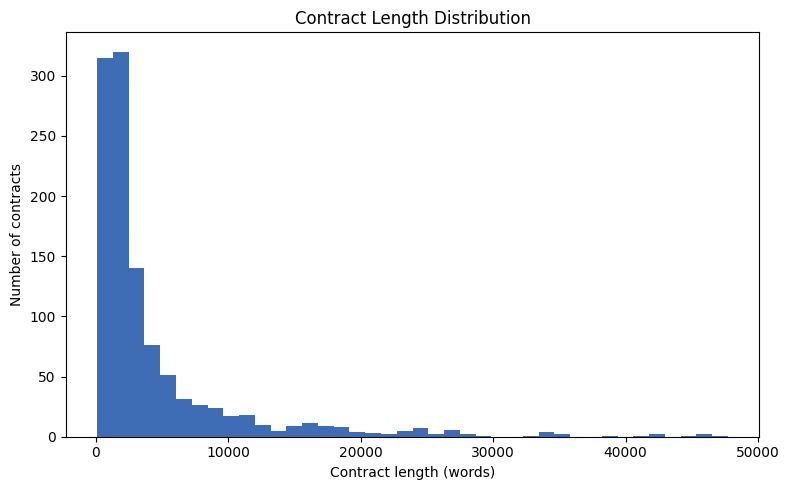

In [10]:

contracts_df["text_length_chars"] = contracts_df["contract_text"].str.len()
contracts_df["text_length_words"] = contracts_df["contract_text"].str.split().apply(len)

print(contracts_df["text_length_words"].describe())

plt.figure(figsize=(8, 5))
plt.hist(contracts_df["text_length_words"], bins=40, color="#3f6db5")
plt.xlabel("Contract length (words)")
plt.ylabel("Number of contracts")
plt.title("Contract Length Distribution")
plt.tight_layout()
plt.show()


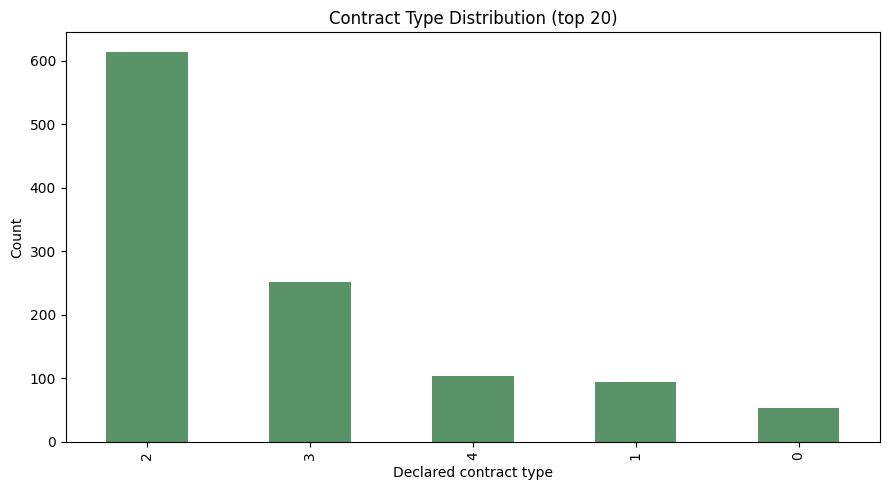

declared_type
2    614
3    251
4    104
1     95
0     53
Name: count, dtype: int64

In [11]:

type_counts = contracts_df["declared_type"].replace("", "unlabeled").value_counts().head(20)

plt.figure(figsize=(9, 5))
type_counts.plot(kind="bar", color="#5a9367")
plt.xlabel("Declared contract type")
plt.ylabel("Count")
plt.title("Contract Type Distribution (top 20)")
plt.tight_layout()
plt.show()

type_counts


In [12]:

def clean_contract_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\u00a0", " ")           # non-breaking space
    text = re.sub(r"[ \t]+", " ", text)           # collapse horizontal whitespace
    text = re.sub(r"\n{3,}", "\n\n", text)        # collapse excessive blank lines
    return text.strip()

before = len(contracts_df)
contracts_df["contract_text"] = contracts_df["contract_text"].apply(clean_contract_text)

contracts_df = contracts_df[contracts_df["contract_text"].str.len() > 0].copy()
contracts_df = contracts_df.drop_duplicates(subset=["contract_text"]).reset_index(drop=True)

after = len(contracts_df)
print(f"Contracts before cleaning: {before}")
print(f"Contracts after removing empty/duplicate rows: {after}")


Contracts before cleaning: 1117
Contracts after removing empty/duplicate rows: 1115


In [13]:

# --- Canonical step library and ordering ---------------------------------
STEP_LIBRARY = [
    "Contract Negotiation",
    "Legal Review",
    "Technical Review",
    "Security Review",
    "Compliance Review",
    "Finance Review",
    "Procurement Review",
    "Manager Approval",
    "Director Approval",
    "Executive Approval",
    "Contract Signing",
    "Document Archive",
]
STEP_ORDER = {step: i for i, step in enumerate(STEP_LIBRARY)}

def order_steps(step_set):
    """De-duplicate and sort a collection of step names into canonical order."""
    return sorted(set(step_set), key=lambda s: STEP_ORDER.get(s, len(STEP_LIBRARY)))


In [14]:

# --- Signal detection helpers ---------------------------------------------
# Each detector looks for real evidence in (a) the contract text and
# (b) the clause-level signals pulled from the supporting CSVs in Section 3.

def _text_has_any(text, keywords):
    t = text.lower()
    return any(kw in t for kw in keywords)

def _signals_have_any(signals, keywords):
    s = " | ".join(signals).lower()
    return any(kw in s for kw in keywords)

def is_nda(text, signals, declared_type):
    kws = ["non-disclosure", "nondisclosure", "confidentiality agreement", "nda"]
    return ("nda" in declared_type.lower()) or _text_has_any(text, kws) or _signals_have_any(signals, ["confidential"])

def is_software_or_technical(text, signals, declared_type):
    kws = ["software", "development agreement", "technical services", "saas",
           "source code", "api", "hosting", "system integration", "it services"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["ip rights", "source code", "license"])

def has_financial_obligation(text, signals, declared_type):
    kws = ["payment", "fee", "invoice", "purchase price", "consideration",
           "compensation", "$", "usd", "cost", "expense"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["payment", "revenue", "price"])

def has_large_value_signal(text, signals, declared_type):
    # Looks for explicit large monetary figures (>= 6 digits) or contract-value language.
    money_matches = re.findall(r"\$\s?([\d,]{6,})", text)
    big_number = any(int(m.replace(",", "")) >= 100000 for m in money_matches if m.replace(",", "").isdigit())
    kws = ["contract value", "total contract price", "aggregate amount"]
    return big_number or _text_has_any(text, kws)

def has_confidentiality(text, signals, declared_type):
    kws = ["confidential", "non-disclosure", "trade secret"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["confidential"])

def has_ip_clause(text, signals, declared_type):
    kws = ["intellectual property", "copyright", "patent", "trademark", "proprietary rights"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["intellectual property", "ip"])

def has_data_protection(text, signals, declared_type):
    kws = ["personal data", "data protection", "gdpr", "privacy", "data processing"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["data protection", "privacy"])

def has_international_party(text, signals, declared_type):
    kws = ["foreign", "international", "cross-border", "export control",
           "governing law of", "united kingdom", "european union", "overseas"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["international", "export"])

def has_payment_terms(text, signals, declared_type):
    kws = ["net 30", "net 60", "payment terms", "installment", "milestone payment"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["payment terms"])

def has_termination_clause(text, signals, declared_type):
    kws = ["termination", "terminate this agreement", "right to terminate"]
    return _text_has_any(text, kws) or _signals_have_any(signals, ["termination"])

def has_negotiated_terms(text, signals, declared_type):
    kws = ["negotiate", "negotiation", "mutually agreed", "subject to further discussion"]
    return _text_has_any(text, kws)


In [15]:

# --- Rule definitions -------------------------------------------------
# Each rule: rule_name, condition (callable + human description), generated_steps,
# explanation. Rules are evaluated independently and their steps are UNIONED,
# then sorted into canonical order. This lets a single contract correctly
# trigger multiple concerns at once (e.g. an international software deal).

WORKFLOW_RULES = [
    {
        "rule_name": "baseline_every_contract",
        "condition_desc": "Always true — every contract needs legal sign-off and archival.",
        "condition": lambda text, sig, dt: True,
        "generated_steps": ["Legal Review", "Contract Signing", "Document Archive"],
        "explanation": "Every contract, regardless of type, must pass legal review before "
                        "signing and must be archived afterward for record-keeping and audit.",
    },
    {
        "rule_name": "nda_contract",
        "condition_desc": "Contract text/type indicates an NDA or confidentiality agreement.",
        "condition": is_nda,
        "generated_steps": ["Legal Review", "Manager Approval", "Contract Signing", "Document Archive"],
        "explanation": "NDAs are low financial risk but carry confidentiality exposure, so they "
                        "require legal review and a single manager sign-off rather than the full "
                        "approval chain.",
    },
    {
        "rule_name": "software_or_technical_contract",
        "condition_desc": "Contract concerns software/technical services (keywords or IP/license clause signals).",
        "condition": is_software_or_technical,
        "generated_steps": ["Technical Review", "Security Review", "Manager Approval"],
        "explanation": "Technical agreements (development, SaaS, integrations) need a technical "
                        "feasibility check and a security review of any system access or data "
                        "exchange before a manager approves scope and cost.",
    },
    {
        "rule_name": "financial_obligation_present",
        "condition_desc": "Contract text/clauses reference payment, fees, invoicing, or cost.",
        "condition": has_financial_obligation,
        "generated_steps": ["Finance Review"],
        "explanation": "Any contract creating a financial obligation must be checked by Finance "
                        "for budget availability and accounting treatment.",
    },
    {
        "rule_name": "large_value_contract",
        "condition_desc": "Contract references a monetary figure >= 100,000 or explicit high-value language.",
        "condition": has_large_value_signal,
        "generated_steps": ["Finance Review", "Director Approval", "Executive Approval"],
        "explanation": "High-value contracts carry outsized financial risk, so they escalate past "
                        "a single manager to Director and Executive approval in addition to Finance "
                        "Review.",
    },
    {
        "rule_name": "confidentiality_clause",
        "condition_desc": "Contract text/clauses contain confidentiality or trade-secret language.",
        "condition": has_confidentiality,
        "generated_steps": ["Legal Review"],
        "explanation": "Confidentiality obligations increase legal exposure and are reinforced "
                        "here even outside the standalone-NDA case (e.g. a confidentiality clause "
                        "embedded in a larger commercial contract).",
    },
    {
        "rule_name": "intellectual_property_clause",
        "condition_desc": "Contract text/clauses reference IP, copyright, patent, or proprietary rights.",
        "condition": has_ip_clause,
        "generated_steps": ["Legal Review", "Technical Review"],
        "explanation": "IP assignment/licensing terms need legal scrutiny of ownership language "
                        "and a technical check that the described deliverables match what's "
                        "actually being built or licensed.",
    },
    {
        "rule_name": "data_protection_clause",
        "condition_desc": "Contract text/clauses reference personal data, GDPR, or privacy obligations.",
        "condition": has_data_protection,
        "generated_steps": ["Compliance Review", "Security Review"],
        "explanation": "Processing personal data triggers regulatory compliance obligations and "
                        "requires a security review of how that data will be protected.",
    },
    {
        "rule_name": "international_party",
        "condition_desc": "Contract text/clauses indicate a foreign/cross-border counterparty or governing law.",
        "condition": has_international_party,
        "generated_steps": ["Compliance Review", "Executive Approval"],
        "explanation": "Cross-border contracts must clear export-control/compliance review and "
                        "are escalated to Executive Approval given the added jurisdictional risk.",
    },
    {
        "rule_name": "payment_terms_specified",
        "condition_desc": "Contract text/clauses specify concrete payment terms (e.g. net-30, milestones).",
        "condition": has_payment_terms,
        "generated_steps": ["Finance Review", "Procurement Review"],
        "explanation": "Defined payment schedules need Finance sign-off on cash-flow impact and "
                        "Procurement validation that terms match vendor policy.",
    },
    {
        "rule_name": "termination_clause_present",
        "condition_desc": "Contract text/clauses define termination rights.",
        "condition": has_termination_clause,
        "generated_steps": ["Legal Review"],
        "explanation": "Termination terms define exit risk and are reinforced here as a legal "
                        "review trigger independent of the baseline rule.",
    },
    {
        "rule_name": "negotiated_terms_present",
        "condition_desc": "Contract text indicates terms are still subject to negotiation.",
        "condition": has_negotiated_terms,
        "generated_steps": ["Contract Negotiation"],
        "explanation": "If the text signals terms are not yet final, a negotiation step precedes "
                        "review so reviewers evaluate the settled version.",
    },
]

print(f"Defined {len(WORKFLOW_RULES)} deterministic workflow rules.")


Defined 12 deterministic workflow rules.


In [16]:

def generate_workflow(text, signals, declared_type):
    """Apply every rule engine condition to a contract and union the steps
    of every rule that fires. Returns (steps, fired_rule_names)."""
    fired = []
    steps = set()
    for rule in WORKFLOW_RULES:
        if rule["condition"](text, signals, declared_type):
            fired.append(rule["rule_name"])
            steps.update(rule["generated_steps"])
    return order_steps(steps), fired


def explain_workflow(fired_rule_names):
    """Human-readable justification listing which rules fired and why."""
    lines = []
    for name in fired_rule_names:
        rule = next(r for r in WORKFLOW_RULES if r["rule_name"] == name)
        lines.append(f"- [{rule['rule_name']}] {rule['explanation']}")
    return "\n".join(lines)


# --- Export the rule definitions for auditability -------------------------
rules_export = [
    {
        "rule_name": r["rule_name"],
        "condition": r["condition_desc"],
        "generated_steps": r["generated_steps"],
        "explanation": r["explanation"],
    }
    for r in WORKFLOW_RULES
]

with open("workflow_rules.json", "w", encoding="utf-8") as f:
    json.dump(rules_export, f, indent=2, ensure_ascii=False)

print("Saved workflow_rules.json with", len(rules_export), "rules.")


Saved workflow_rules.json with 12 rules.


In [17]:

generated_steps_col = []
fired_rules_col = []

for _, row in contracts_df.iterrows():
    steps, fired = generate_workflow(row["contract_text"], row["clause_signals"], row["declared_type"])
    generated_steps_col.append(steps)
    fired_rules_col.append(fired)

contracts_df["workflow_steps"] = generated_steps_col
contracts_df["fired_rules"] = fired_rules_col

dynamic_workflow_dataset = contracts_df[["contract_text", "workflow_steps"]].copy()
# Store the list as a JSON string so the CSV round-trips cleanly.
dynamic_workflow_dataset["workflow_steps"] = dynamic_workflow_dataset["workflow_steps"].apply(
    lambda steps: json.dumps(steps)
)

dynamic_workflow_dataset.to_csv("dynamic_workflow_dataset.csv", index=False)
print("Saved dynamic_workflow_dataset.csv with", len(dynamic_workflow_dataset), "rows.")
dynamic_workflow_dataset.head(3)


Saved dynamic_workflow_dataset.csv with 1115 rows.


,contract_text,workflow_steps
0,"-1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT entered into by and between SYSTEMS APPLICATIONS PRODUCTS (AFRICA) (PTY) LIMITED (""SAP AFRICA"") a company incorporated in accorda...","[""Contract Negotiation"", ""Legal Review"", ""Technical Review"", ""Security Review"", ""Compliance Review"", ""Finance Review"", ""Procurement Review"", ""Manager Approval"", ""Executive Approval"", ""Contract Sig..."
1,"Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AGREEMENT\n\n This Collaborative Development and Commercialization Agreement (""Agree...","[""Contract Negotiation"", ""Legal Review"", ""Technical Review"", ""Security Review"", ""Compliance Review"", ""Finance Review"", ""Manager Approval"", ""Director Approval"", ""Executive Approval"", ""Contract Sign..."
2,"CO-BRANDING AND ADVERTISING AGREEMENT\n\nTHIS CO-BRANDING AND ADVERTISING AGREEMENT (the ""Agreement"") is made as of June 21, 1999 (the ""Effective Date"") by and between I-ESCROW, INC., with its pri...","[""Contract Negotiation"", ""Legal Review"", ""Technical Review"", ""Security Review"", ""Compliance Review"", ""Finance Review"", ""Manager Approval"", ""Executive Approval"", ""Contract Signing"", ""Document Archi..."


Number of generated workflows: 1115
Average workflow length: 7.96

count    1115.000000
mean        7.959641
std         2.147017
min         3.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        12.000000
Name: workflow_length, dtype: float64


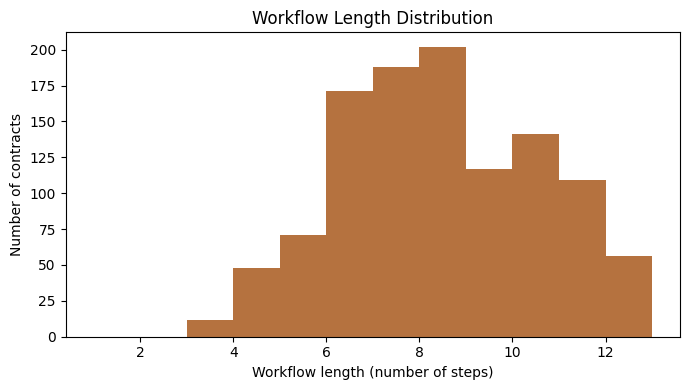

In [18]:

contracts_df["workflow_length"] = contracts_df["workflow_steps"].apply(len)

print("Number of generated workflows:", len(contracts_df))
print("Average workflow length:", contracts_df["workflow_length"].mean().round(2))
print()
print(contracts_df["workflow_length"].describe())

plt.figure(figsize=(7, 4))
plt.hist(contracts_df["workflow_length"], bins=range(1, STEP_LIBRARY.__len__() + 2), color="#b5723f")
plt.xlabel("Workflow length (number of steps)")
plt.ylabel("Number of contracts")
plt.title("Workflow Length Distribution")
plt.tight_layout()
plt.show()


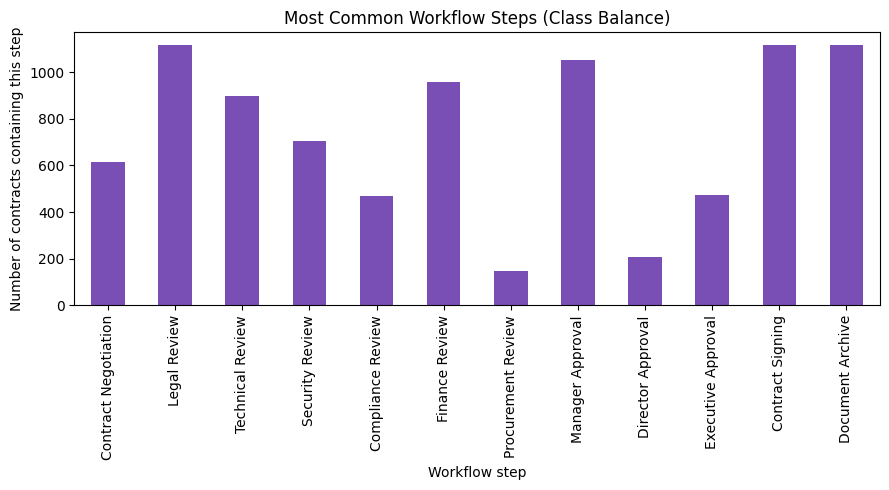

Class imbalance (min vs max step frequency): 148 vs 1115


Contract Negotiation     617
Legal Review            1115
Technical Review         898
Security Review          703
Compliance Review        469
Finance Review           958
Procurement Review       148
Manager Approval        1054
Director Approval        209
Executive Approval       474
Contract Signing        1115
Document Archive        1115
dtype: int64

In [19]:

step_counter = Counter()
for steps in contracts_df["workflow_steps"]:
    step_counter.update(steps)

step_freq = pd.Series(step_counter).reindex(STEP_LIBRARY).fillna(0).astype(int)

plt.figure(figsize=(9, 5))
step_freq.plot(kind="bar", color="#7a4fb5")
plt.xlabel("Workflow step")
plt.ylabel("Number of contracts containing this step")
plt.title("Most Common Workflow Steps (Class Balance)")
plt.tight_layout()
plt.show()

print("Class imbalance (min vs max step frequency):", step_freq.min(), "vs", step_freq.max())
step_freq


In [20]:

# --- Print worked examples: contract text + generated workflow + why ------
for i in random.sample(range(len(contracts_df)), k=min(3, len(contracts_df))):
    row = contracts_df.iloc[i]
    print("=" * 90)
    print("CONTRACT SAMPLE (first 300 chars):")
    print(row["contract_text"][:300].replace("\n", " "), "...")
    print()
    print("GENERATED WORKFLOW:", row["workflow_steps"])
    print()
    print("REASONING:")
    print(explain_workflow(row["fired_rules"]))
    print()


CONTRACT SAMPLE (first 300 chars):
Exhibit 10.1 JACKSONVILLE JAGUARS SPONSORSHIP AGREEMENT This Sponsorship Agreement (this "Agreement") is entered into as of November 27, 2017 (the "Execution Date") by and between Jacksonville Jaguars, LLC, a Delaware limited liability company ("Club"), and The ARC Group, Inc., a Florida corporation ...

GENERATED WORKFLOW: ['Contract Negotiation', 'Legal Review', 'Technical Review', 'Security Review', 'Finance Review', 'Procurement Review', 'Manager Approval', 'Director Approval', 'Executive Approval', 'Contract Signing', 'Document Archive']

REASONING:
- [baseline_every_contract] Every contract, regardless of type, must pass legal review before signing and must be archived afterward for record-keeping and audit.
- [nda_contract] NDAs are low financial risk but carry confidentiality exposure, so they require legal review and a single manager sign-off rather than the full approval chain.
- [software_or_technical_contract] Technical agreements (develop

In [21]:

def steps_to_text(steps):
    return " -> ".join(steps)

seq_df = contracts_df[["contract_text", "workflow_steps"]].copy()
seq_df["target_text"] = seq_df["workflow_steps"].apply(steps_to_text)
# Keep the model's job scoped to routing, not re-reading entire contracts word
# for word — prompt it explicitly with an instruction, FLAN-T5 style.
seq_df["input_text"] = "Generate the contract workflow steps for: " + seq_df["contract_text"]

seq_df = seq_df[(seq_df["input_text"].str.len() > 0) & (seq_df["target_text"].str.len() > 0)]
seq_df = seq_df.reset_index(drop=True)

print(seq_df.shape)
seq_df[["input_text", "target_text"]].head(2)


(1115, 4)


,input_text,target_text
0,"Generate the contract workflow steps for: -1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT entered into by and between SYSTEMS APPLICATIONS PRODUCTS (AFRICA) (PTY) LIMITED (""SAP ...",Contract Negotiation -> Legal Review -> Technical Review -> Security Review -> Compliance Review -> Finance Review -> Procurement Review -> Manager Approval -> Executive Approval -> Contract Signi...
1,"Generate the contract workflow steps for: Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AGREEMENT\n\n This Collaborative Developme...",Contract Negotiation -> Legal Review -> Technical Review -> Security Review -> Compliance Review -> Finance Review -> Manager Approval -> Director Approval -> Executive Approval -> Contract Signin...


In [22]:

# 80 / 10 / 10 split
n = len(seq_df)
shuffled = seq_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_train = int(n * 0.8)
n_val = int(n * 0.1)

train_df = shuffled.iloc[:n_train]
val_df = shuffled.iloc[n_train:n_train + n_val]
test_df = shuffled.iloc[n_train + n_val:]

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df[["input_text", "target_text"]], preserve_index=False),
    "validation": Dataset.from_pandas(val_df[["input_text", "target_text"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["input_text", "target_text"]], preserve_index=False),
})
raw_datasets


train: 892 val: 111 test: 112


DatasetDict({
    train: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 892
    })
    validation: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 111
    })
    test: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 112
    })
})

In [23]:

MODEL_CHECKPOINT = "google/flan-t5-base"
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)


def preprocess_batch(examples):
    model_inputs = tokenizer(
        examples["input_text"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples["target_text"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


tokenized_datasets = raw_datasets.map(
    preprocess_batch,
    batched=True,
    remove_columns=raw_datasets["train"].column_names,
)
tokenized_datasets


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/892 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/112 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 892
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 111
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 112
    })
})

In [24]:

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

OUTPUT_DIR = "/kaggle/working/dynamic-workflow-builder"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=6,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    logging_steps=25,
    report_to="none",
    seed=SEED,
)


In [25]:

rouge = evaluate.load("rouge")

def postprocess_text(preds, labels):
    preds = [p.strip() for p in preds]
    labels = [l.strip() for l in labels]
    return preds, labels


def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    rouge_result = rouge.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True
    )

    exact_matches = [
        1.0 if p.strip().lower() == l.strip().lower() else 0.0
        for p, l in zip(decoded_preds, decoded_labels)
    ]
    exact_match_accuracy = float(np.mean(exact_matches)) if exact_matches else 0.0

    result = {k: round(v * 100, 2) for k, v in rouge_result.items()}
    result["exact_match_accuracy"] = round(exact_match_accuracy * 100, 2)
    return result


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Exact Match Accuracy
1,0.121337,0.105483,84.680000,82.910000,84.390000,84.490000,12.610000
2,0.100685,0.088213,89.140000,87.480000,89.070000,89.090000,22.520000
3,0.082901,0.083756,89.760000,88.130000,89.700000,89.730000,24.320000
4,0.061494,0.087416,90.230000,88.450000,90.140000,90.180000,27.030000
5,0.048436,0.091488,89.500000,87.700000,89.480000,89.480000,27.030000
6,0.035381,0.098834,90.500000,88.720000,90.390000,90.430000,28.830000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


***** train metrics *****
  epoch                    =        6.0
  total_flos               =  3413130GF
  train_loss               =     0.0965
  train_runtime            = 5:29:34.60
  train_samples_per_second =      0.271
  train_steps_per_second   =      0.034


In [ ]:
# --- Save Flan-T5 Model & Start FastAPI Ngrok Server ---
trainer.save_model("/kaggle/working/dynamic-workflow-builder-final")
tokenizer.save_pretrained("/kaggle/working/dynamic-workflow-builder-final")
print("Flan-T5 model saved!")

!pip install -q fastapi uvicorn pyngrok nest_asyncio

import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List, Optional
from pyngrok import ngrok
import torch
from transformers import AutoModelForSequenceClassification, AutoModelForSeq2SeqLM, AutoTokenizer
import os
import re

nest_asyncio.apply()
app = FastAPI(title="Unified Kaggle Workflow Recommendation Service")

# Load Deberta
deberta_path = "/kaggle/working/workflow-recommendation-model"
if not os.path.exists(deberta_path):
    deberta_path = "microsoft/deberta-v3-base"
print(f"Loading Deberta classification model from {deberta_path}...")
try:
    deberta_tokenizer = AutoTokenizer.from_pretrained(deberta_path)
    deberta_model = AutoModelForSequenceClassification.from_pretrained(deberta_path)
    deberta_model.eval()
    if torch.cuda.is_available():
        deberta_model.to("cuda")
    print("Deberta loaded successfully!")
except Exception as e:
    print(f"Failed to load Deberta: {e}")
    deberta_model = None

# Load Flan-T5
flant5_path = "/kaggle/working/dynamic-workflow-builder-final"
print(f"Loading Flan-T5 step generator from {flant5_path}...")
try:
    flant5_tokenizer = AutoTokenizer.from_pretrained(flant5_path)
    flant5_model = AutoModelForSeq2SeqLM.from_pretrained(flant5_path)
    flant5_model.eval()
    if torch.cuda.is_available():
        flant5_model.to("cuda")
    print("Flan-T5 loaded successfully!")
except Exception as e:
    print(f"Failed to load Flan-T5: {e}")
    flant5_model = None

class RecommendWorkflowRequest(BaseModel):
    contract_text: str
    clause_types: List[str] = []
    contract_type: str = ""

class WorkflowStepResponse(BaseModel):
    step_name: str
    role_id: int
    description: str

class RecommendWorkflowResponse(BaseModel):
    workflow_type: str
    steps: List[WorkflowStepResponse]
    reasons: str
    workflow_name: Optional[str] = None

STEP_DETAILS_MAPPING = {
    "Contract Negotiation": {"role_id": 4, "description": "Thương thảo các điều khoản chưa thống nhất giữa các bên ký kết."},
    "Legal Review": {"role_id": 4, "description": "Rà soát tính pháp lý, rủi ro điều khoản và tuân thủ pháp luật."},
    "Technical Review": {"role_id": 7, "description": "Thẩm định tính khả thi kỹ thuật và giải pháp công nghệ đề xuất."},
    "Security Review": {"role_id": 8, "description": "Đánh giá an toàn thông tin, bảo mật dữ liệu và hệ thống."},
    "Compliance Review": {"role_id": 9, "description": "Kiểm tra sự tuân thủ các quy định nội bộ và tiêu chuẩn ngành."},
    "Finance Review": {"role_id": 6, "description": "Thẩm định ngân sách, dòng tiền và nghĩa vụ tài chính phát sinh."},
    "Procurement Review": {"role_id": 10, "description": "Đánh giá năng lực nhà cung cấp, đơn giá và chính sách mua sắm."},
    "Manager Approval": {"role_id": 5, "description": "Phê duyệt cấp quản lý trực tiếp về mặt chủ trương và ngân sách."},
    "Director Approval": {"role_id": 11, "description": "Phê duyệt cấp Giám đốc bộ phận đối với các hợp đồng/dự án lớn."},
    "Executive Approval": {"role_id": 11, "description": "Phê duyệt tối cao từ Ban điều hành/Tổng giám đốc."},
    "Contract Signing": {"role_id": 4, "description": "Đại diện có thẩm quyền thực hiện ký kết hợp đồng chính thức."},
    "Document Archive": {"role_id": 4, "description": "Lưu trữ hợp đồng đã ký kết vào hệ thống và bàn giao bản cứng."}
}

INDEX_TO_WORKFLOW_ID = {
    0: 'WF_EMPLOYMENT',
    1: 'WF_EXECUTIVE',
    2: 'WF_GENERAL',
    3: 'WF_NDA',
    4: 'WF_PROCUREMENT',
    5: 'WF_PURCHASE',
    6: 'WF_SERVICE',
    7: 'WF_VENDOR'
}

@app.post("/api/v1/recommend_workflow", response_model=RecommendWorkflowResponse)
async def recommend_workflow_api(payload: RecommendWorkflowRequest):
    workflow_type = "WF_GENERAL"
    if deberta_model is not None:
        try:
            device = "cuda" if torch.cuda.is_available() else "cpu"
            inputs = deberta_tokenizer(
                payload.contract_text,
                return_tensors="pt",
                truncation=True,
                max_length=512
            ).to(device)
            with torch.no_grad():
                outputs = deberta_model(**inputs)
            pred_idx = torch.argmax(outputs.logits, dim=-1).item()
            if hasattr(deberta_model.config, 'id2label') and deberta_model.config.id2label:
                workflow_type = deberta_model.config.id2label.get(pred_idx, "WF_GENERAL")
            else:
                workflow_type = INDEX_TO_WORKFLOW_ID.get(pred_idx, "WF_GENERAL")
        except Exception as e:
            print(f"Classification error: {e}")

    steps_list = []
    reasons = "AI model dynamically recommended the workflow steps and mapped roles."
    if flant5_model is not None:
        try:
            device = "cuda" if torch.cuda.is_available() else "cpu"
            prompt = "Generate the contract workflow steps for: " + payload.contract_text
            inputs = flant5_tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=512
            ).to(device)
            with torch.no_grad():
                outputs = flant5_model.generate(**inputs, max_new_tokens=64)
            decoded = flant5_tokenizer.decode(outputs[0], skip_special_tokens=True)
            parsed_steps = [s.strip() for s in decoded.split("->") if s.strip()]
            
            for step_name in parsed_steps:
                if step_name in STEP_DETAILS_MAPPING:
                    details = STEP_DETAILS_MAPPING[step_name]
                    # Generate description dynamically using Flan-T5 based on contract context
                    desc_prompt = f"Based on this contract context: '{payload.contract_text[:300]}...', explain the contract approval step '{step_name}' in 1 short Vietnamese sentence:"
                    desc_inputs = flant5_tokenizer(desc_prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
                    with torch.no_grad():
                        desc_outputs = flant5_model.generate(**desc_inputs, max_new_tokens=64)
                    dynamic_desc = flant5_tokenizer.decode(desc_outputs[0], skip_special_tokens=True).strip()
                    
                    if len(dynamic_desc) < 5:
                        dynamic_desc = details["description"]
                        
                    steps_list.append(WorkflowStepResponse(
                        step_name=step_name,
                        role_id=details["role_id"],
                        description=dynamic_desc
                    ))
        except Exception as e:
            print(f"Step generation error: {e}")

    if not steps_list:
        default_steps = ["Legal Review", "Contract Signing", "Document Archive"]
        for step_name in default_steps:
            details = STEP_DETAILS_MAPPING[step_name]
            steps_list.append(WorkflowStepResponse(
                step_name=step_name,
                role_id=details["role_id"],
                description=details["description"]
            ))

    workflow_name = f"{workflow_type.replace('WF_', '').title()} Approval Workflow"
    return RecommendWorkflowResponse(
        workflow_type=workflow_type,
        steps=steps_list,
        reasons=reasons,
        workflow_name=workflow_name
    )

NGROK_TOKEN = os.environ.get("NGROK_AUTH_TOKEN", "2z2Jys005c289EvZifDWi1ViBBr_7nZ6ASrHHT7qpoJ3DgmQU")
ngrok.set_auth_token(NGROK_TOKEN)
try:
    public_url = ngrok.connect(8000)
    print("=== NGROK PUBLIC URL ===")
    print(public_url)
    print("========================")
except Exception as e:
    print(f"Ngrok connection failed: {e}")

uvicorn.run(app, host="0.0.0.0", port=8000)
